In [2]:
"""
xLSTM for BiH air-quality forecasting.

Wires into the real bih_shared.py (from shared_setup.ipynb), which exposes:
    load_split, load_groups, load_windows, load_coords, load_panel,
    target, context, mase_scale, score, aggregate

Key thing this respects that a naive port wouldn't: eval_windows.csv is
VALIDATION-ONLY (origins are drawn only from 2024, midnight, one per day).
There is no equivalent frozen file for training windows, so training
origins are built here with the *same* eligibility rule the notebook uses
for eval (min_real_target_hours, some real history in the preceding week),
just applied to the 2021-2023 train range instead. That keeps train/val
windowing philosophy identical without inventing a second convention.
"""

import os
import sys
import subprocess
import math
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

# ---- pull the shared artifacts + the clean dataset, exactly as the other
# tracks do -------------------------------------------------------------
subprocess.run([sys.executable, "-m", "pip", "install", "-q", "gdown"], check=True)
import gdown

SHARED_DIR = "shared"
gdown.download_folder(id="1ivElb2AifDNvIg47Ii6dV_XP9aO14WSE", output=SHARED_DIR, quiet=True)
sys.path.append(SHARED_DIR)
import bih_shared as bs

CLEAN_CSV = "bih_hourly_clean.csv"
if not os.path.exists(CLEAN_CSV):
    gdown.download(id="1QyfzghimgyRhQ735k42JetDEoK5kfGZJ", output=CLEAN_CSV, quiet=False)


# ---------------------------------------------------------------------------
# 1. Data loading — reuse the frozen split/partitions, build train origins
#    with the same rule the notebook used for eval, applied to 2021-2023
# ---------------------------------------------------------------------------

def build_train_origins(panel, split, station, pollutant, horizon):
    """Mirrors shared_setup.ipynb cell 14's eligibility rule (target-side
    only: >= min_real_target_hours real+unfilled hours in the target, some
    finite value somewhere in the preceding week), but over the train range
    instead of 2024, so training and eval share one windowing philosophy."""
    s = panel[(station, pollutant)]
    y = s.y.to_numpy()
    filled = s.filled.to_numpy()
    real = ~np.isnan(y) & ~filled

    stride = split["origin_stride_hours"]
    hour_of_day = split["origin_hour_of_day"]
    min_real_target = split["masking"]["min_real_target_hours"]

    train_start = pd.Timestamp(split["train"]["start"])
    train_end = pd.Timestamp(split["train"]["end"])
    candidates = s.index[(s.index >= train_start) & (s.index <= train_end)
                          & (s.index.hour == hour_of_day)]

    origins = []
    for ts in candidates:
        o = s.index.get_loc(ts)
        if o + horizon > len(y):
            continue
        if real[o:o + horizon].sum() < min_real_target:
            continue
        if not np.isfinite(y[max(0, o - 168):o]).any():
            continue
        origins.append(ts)
    return origins


class WindowDataset(Dataset):
    """One item = one forecast origin. Input is `lookback` hours of context
    (bs.context — filled values allowed there), target is `horizon` hours
    plus the mask of which of those hours are real+unfilled (bs.target).

    Values are standardized with train-set mu/sigma before hitting the
    model — xLSTM's exponential gating (exp(i_tilde - m_new)) is sensitive
    to input scale before the stabilizer state settles, and raw PM10/NO2/etc
    magnitudes (tens to hundreds) push it toward collapsing to the mean."""

    def __init__(self, panel, station, pollutant, origins, lookback, horizon, mu, sigma):
        self.panel = panel
        self.station = station
        self.pollutant = pollutant
        self.origins = origins
        self.lookback = lookback
        self.horizon = horizon
        self.mu = mu
        self.sigma = sigma if sigma > 1e-6 else 1.0

    def __len__(self):
        return len(self.origins)

    def __getitem__(self, idx):
        origin = self.origins[idx]
        ctx = bs.context(self.panel, self.station, self.pollutant, origin, self.lookback)

        # bs.context() returns fewer than `lookback` hours when the origin is
        # close to the start of the panel (not enough history yet, e.g. early
        # 2021). Left-pad with NaN so it's short-context, not wrong-context —
        # the observed-flag channel below marks the padding as unobserved,
        # same as it marks real gaps.
        if len(ctx) < self.lookback:
            pad = np.full(self.lookback - len(ctx), np.nan, dtype=ctx.dtype)
            ctx = np.concatenate([pad, ctx])

        observed = np.isfinite(ctx).astype(np.float32)
        ctx_norm = (ctx - self.mu) / self.sigma
        ctx_norm = np.nan_to_num(ctx_norm, nan=0.0).astype(np.float32)  # 0 == mean, in normalized space

        y, mask = bs.target(self.panel, self.station, self.pollutant, origin, self.horizon)
        y_norm = np.nan_to_num((y - self.mu) / self.sigma, nan=0.0).astype(np.float32)

        x = np.stack([ctx_norm, observed], axis=-1)  # (lookback, 2): normalized value + observed-flag
        return (torch.from_numpy(x), torch.from_numpy(y_norm),
                torch.from_numpy(mask.astype(np.float32)))


# ---------------------------------------------------------------------------
# 2. xLSTM blocks — simplified sLSTM (scalar memory, exponential gating)
#    and mLSTM (matrix memory) per Beck et al. 2024, stacked alternately
# ---------------------------------------------------------------------------

class sLSTMCell(nn.Module):
    """Scalar-memory LSTM cell with exponential input/forget gating and a
    stabilizer state (m_t), as in the xLSTM paper. Good for spike/plume-like
    dynamics (e.g. SO2)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.W = nn.Linear(input_size, 4 * hidden_size)
        self.R = nn.Linear(hidden_size, 4 * hidden_size, bias=False)

    def forward(self, x_t, state):
        h, c, n, m = state
        gates = self.W(x_t) + self.R(h)
        z, i_tilde, f_tilde, o_tilde = gates.chunk(4, dim=-1)

        z = torch.tanh(z)
        o = torch.sigmoid(o_tilde)

        # stabilized exponential gating
        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        c_new = f * c + i * z
        n_new = f * n + i
        h_new = o * (c_new / n_new.clamp_min(1e-6))

        return h_new, (h_new, c_new, n_new, m_new)

    def init_state(self, batch_size, device):
        z = torch.zeros(batch_size, self.hidden_size, device=device)
        return (z, z, z, z)


class mLSTMCell(nn.Module):
    """Matrix-memory LSTM cell (parallelizable, larger storage capacity).
    Good default for the smoother diurnal patterns (PM10, NO2, O3)."""

    def __init__(self, input_size, hidden_size):
        super().__init__()
        self.hidden_size = hidden_size
        self.Wq = nn.Linear(input_size, hidden_size)
        self.Wk = nn.Linear(input_size, hidden_size)
        self.Wv = nn.Linear(input_size, hidden_size)
        self.Wi = nn.Linear(input_size, 1)
        self.Wf = nn.Linear(input_size, 1)
        self.Wo = nn.Linear(input_size, hidden_size)

    def forward(self, x_t, state):
        C, n, m = state  # C: (B,H,H) matrix memory, n: (B,H), m: (B,1) stabilizer

        q = self.Wq(x_t)
        k = self.Wk(x_t) / math.sqrt(self.hidden_size)
        v = self.Wv(x_t)
        i_tilde = self.Wi(x_t)
        f_tilde = self.Wf(x_t)
        o = torch.sigmoid(self.Wo(x_t))

        m_new = torch.maximum(f_tilde + m, i_tilde)
        i = torch.exp(i_tilde - m_new)
        f = torch.exp(f_tilde + m - m_new)

        C_new = f.unsqueeze(-1) * C + i.unsqueeze(-1) * torch.einsum("bh,bk->bhk", v, k)
        n_new = f * n + i * k

        h = o * torch.einsum("bhk,bk->bh", C_new, q) / \
            torch.einsum("bh,bh->b", n_new, q).clamp_min(1e-6).unsqueeze(-1)

        return h, (C_new, n_new, m_new)

    def init_state(self, batch_size, device):
        C = torch.zeros(batch_size, self.hidden_size, self.hidden_size, device=device)
        n = torch.zeros(batch_size, self.hidden_size, device=device)
        m = torch.zeros(batch_size, 1, device=device)
        return (C, n, m)


class xLSTMBlock(nn.Module):
    """One residual block wrapping either an sLSTM or mLSTM cell, run over
    the full sequence."""

    def __init__(self, input_size, hidden_size, kind="m"):
        super().__init__()
        self.kind = kind
        self.cell = mLSTMCell(input_size, hidden_size) if kind == "m" else sLSTMCell(input_size, hidden_size)
        self.norm = nn.LayerNorm(input_size)
        self.proj = nn.Linear(hidden_size, input_size) if hidden_size != input_size else nn.Identity()

    def forward(self, x):
        # x: (B, T, D)
        B, T, D = x.shape
        state = self.cell.init_state(B, x.device)
        x_norm = self.norm(x)
        outs = []
        for t in range(T):
            h, state = self.cell(x_norm[:, t], state)
            outs.append(h)
        h_seq = torch.stack(outs, dim=1)
        return x + self.proj(h_seq)  # residual


class xLSTMForecaster(nn.Module):
    def __init__(self, n_features, hidden_size=64, horizon=24, block_types=("m", "s", "m", "s")):
        super().__init__()
        self.in_proj = nn.Linear(n_features, hidden_size)
        self.blocks = nn.ModuleList([
            xLSTMBlock(hidden_size, hidden_size, kind=k) for k in block_types
        ])
        self.head = nn.Linear(hidden_size, horizon)

    def forward(self, x):
        # x: (B, lookback, n_features)
        h = self.in_proj(x)
        for block in self.blocks:
            h = block(h)
        return self.head(h[:, -1])  # (B, horizon)


# ---------------------------------------------------------------------------
# 3. Training + evaluation, scored the same way as baseline_metrics.csv
# ---------------------------------------------------------------------------

def masked_l1_loss(pred, y, mask):
    """MAE over real+unfilled target hours only — matches split.json's
    masking rule and bs.score's own masking."""
    err = torch.abs(pred - y) * mask
    return err.sum() / mask.sum().clamp_min(1)


def train_one_station(station, pollutant, lookback=168, horizon=24,
                       hidden_size=64, epochs=20, batch_size=64, lr=1e-3, device="cpu"):

    split = bs.load_split(SHARED_DIR)
    groups = bs.load_groups(SHARED_DIR)
    status = groups["by_station"].get(station, {}).get(pollutant)
    if status != "ok":
        raise ValueError(f"{station}-{pollutant} is '{status}', not eligible for training")

    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)
    windows = bs.load_windows(SHARED_DIR)  # 2024 only — this is the eval set

    # standardize using TRAIN period only (2021-2023) — using 2024 here would
    # leak validation-period statistics into training, same principle as the
    # PM2.5/PM10 ratio being fit on train only in shared_setup.ipynb cell 18
    s = panel[(station, pollutant)]
    train_start, train_end = pd.Timestamp(split["train"]["start"]), pd.Timestamp(split["train"]["end"])
    train_vals = s.y.to_numpy()[(s.index >= train_start) & (s.index <= train_end)]
    mu, sigma = float(np.nanmean(train_vals)), float(np.nanstd(train_vals))

    train_origins = build_train_origins(panel, split, station, pollutant, horizon)
    val_origins = windows[(windows.station == station) & (windows.pollutant == pollutant)] \
        .origin.tolist()

    train_ds = WindowDataset(panel, station, pollutant, train_origins, lookback, horizon, mu, sigma)
    val_ds = WindowDataset(panel, station, pollutant, val_origins, lookback, horizon, mu, sigma)
    train_dl = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
    val_dl = DataLoader(val_ds, batch_size=batch_size, shuffle=False)

    model = xLSTMForecaster(n_features=2, hidden_size=hidden_size, horizon=horizon).to(device)
    opt = torch.optim.Adam(model.parameters(), lr=lr)

    for epoch in range(epochs):
        model.train()
        total_loss, total_n = 0.0, 0
        for x, y, mask in train_dl:
            x, y, mask = x.to(device), y.to(device), mask.to(device)
            opt.zero_grad()
            pred = model(x)
            loss = masked_l1_loss(pred, y, mask)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # xLSTM's exponential
            opt.step()                                                       # gates need this
            total_loss += loss.item() * x.size(0)
            total_n += x.size(0)
        print(f"[{station}-{pollutant}] epoch {epoch+1}: train MAE (normalized)={total_loss/total_n:.4f}")

    return model, val_ds, panel, mu, sigma


def evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device="cpu"):
    """Scores with bs.score/bs.mase_scale directly, so numbers are computed
    identically to baseline_metrics.csv and comparable to it row-for-row.
    Predictions are unnormalized back to native units first — mu/sigma are
    only a training-time convenience, baseline_metrics.csv and bs.score()
    both expect native-unit values (e.g. µg/m3)."""
    model.eval()
    rows = []
    val_dl = DataLoader(val_ds, batch_size=64, shuffle=False)

    all_preds = []
    with torch.no_grad():
        for x, y, mask in val_dl:
            pred_norm = model(x.to(device)).cpu().numpy()
            all_preds.append(pred_norm * sigma + mu)
    all_preds = np.concatenate(all_preds)

    for i, origin in enumerate(val_ds.origins):
        y, mask = bs.target(panel, station, pollutant, origin, val_ds.horizon)
        ctx = bs.context(panel, station, pollutant, origin, 512)  # same lookback as baselines
        scale = bs.mase_scale(ctx)
        rows.append({"model": "xlstm", "station": station, "pollutant": pollutant,
                     "origin": origin, **bs.score(all_preds[i], y, mask, scale)})

    result = pd.DataFrame(rows)
    per_pol = bs.aggregate(result.to_dict("records"))

    baseline_row = "persistence_last" if pollutant == "so2" else "persistence_t24"
    print(f"xLSTM vs the bar it needs to clear ({baseline_row}):")
    print(per_pol)
    print(f"(compare against baseline_metrics.csv, pollutant={pollutant}, "
          f"model={baseline_row})")
    return result, per_pol

"""
if __name__ == "__main__":
    STATION, POLLUTANT, LOOKBACK, HORIZON = "Bjelave", "pm10", 168, 24
    model, val_ds, panel, mu, sigma = train_one_station(STATION, POLLUTANT, lookback=LOOKBACK, horizon=HORIZON)
    result, summary = evaluate(model, val_ds, panel, STATION, POLLUTANT, mu, sigma)


def run_all(lookback=168, horizon=24, epochs=20, device="cpu", out_csv="xlstm_results.csv"):
   """ """Loops over every 'ok' station-pollutant pair, trains one xLSTM each,
    and writes per-window scores to out_csv in the same shape as
    baseline_windows.csv — so this can be merged with baseline_metrics.csv's
    aggregation (bs.aggregate) for a single comparison table."""""""
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)  # load once, reuse across pairs

    pairs = [(st, p) for p in bs.POLLUTANTS
              for st in groups["by_pollutant"][p]["ok"]]
    print(f"{len(pairs)} station-pollutant pairs to run")

    all_rows = []
    for station, pollutant in pairs:
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            all_rows.append(result)
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")

    full = pd.concat(all_rows, ignore_index=True)
    full.to_csv(out_csv, index=False)

    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nFULL SUMMARY — xLSTM, per pollutant, native units:\n")
    print(per_pol)
    print(f"\nwrote {out_csv} ({len(full)} rows)")
    print("Compare per_pol against baseline_metrics.csv row by row — remember "
          "SO2's bar is persistence_last, everything else is persistence_t24, "
          "and never average MAE/RMSE across pollutants (CO is mg/m3).")
    return full, per_pol


# to run the full sweep instead of the single-station smoke test above:
#   full, per_pol = run_all()"""

Downloading...
From (original): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ
From (redirected): https://drive.google.com/uc?id=1QyfzghimgyRhQ735k42JetDEoK5kfGZJ&confirm=t&uuid=0335eadd-60d8-4273-bf17-45e8d9fd076a
To: /content/bih_hourly_clean.csv
100%|██████████| 167M/167M [00:01<00:00, 113MB/s]


'\nif __name__ == "__main__":\n    STATION, POLLUTANT, LOOKBACK, HORIZON = "Bjelave", "pm10", 168, 24\n    model, val_ds, panel, mu, sigma = train_one_station(STATION, POLLUTANT, lookback=LOOKBACK, horizon=HORIZON)\n    result, summary = evaluate(model, val_ds, panel, STATION, POLLUTANT, mu, sigma)\n\n\ndef run_all(lookback=168, horizon=24, epochs=20, device="cpu", out_csv="xlstm_results.csv"):\n   Loops over every \'ok\' station-pollutant pair, trains one xLSTM each,\n    and writes per-window scores to out_csv in the same shape as\n    baseline_windows.csv — so this can be merged with baseline_metrics.csv\'s\n    aggregation (bs.aggregate) for a single comparison table."\n    groups = bs.load_groups(SHARED_DIR)\n    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)  # load once, reuse across pairs\n\n    pairs = [(st, p) for p in bs.POLLUTANTS\n              for st in groups["by_pollutant"][p]["ok"]]\n    print(f"{len(pairs)} station-pollutant pairs to run")\n\n    all_rows = []\n    for 

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

Doboj: 4 eligible pollutants total, 4 left to train: [('Doboj', 'pm10'), ('Doboj', 'so2'), ('Doboj', 'no2'), ('Doboj', 'o3')]


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-pm10] epoch 1: train MAE (normalized)=72692.2968
[Doboj-pm10] epoch 2: train MAE (normalized)=1530.2812
[Doboj-pm10] epoch 3: train MAE (normalized)=14.1140
[Doboj-pm10] epoch 4: train MAE (normalized)=0.6282
[Doboj-pm10] epoch 5: train MAE (normalized)=0.5902
[Doboj-pm10] epoch 6: train MAE (normalized)=0.5761
[Doboj-pm10] epoch 7: train MAE (normalized)=61.3468
[Doboj-pm10] epoch 8: train MAE (normalized)=0.5571
[Doboj-pm10] epoch 9: train MAE (normalized)=0.5506
[Doboj-pm10] epoch 10: train MAE (normalized)=0.5417
[Doboj-pm10] epoch 11: train MAE (normalized)=0.5333
[Doboj-pm10] epoch 12: train MAE (normalized)=0.5283
[Doboj-pm10] epoch 13: train MAE (normalized)=0.5221
[Doboj-pm10] epoch 14: train MAE (normalized)=0.5204
[Doboj-pm10] epoch 15: train MAE (normalized)=0.5233
[Doboj-pm10] epoch 16: train MAE (normalized)=0.5176
[Doboj-pm10] epoch 17: train MAE (normalized)=0.5148
[Doboj-pm10] epoch 18: train MAE (normalized)=0.5103
[Doboj-pm10] epoch 19: train MAE (normalized)=

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-so2] epoch 1: train MAE (normalized)=58990.1554
[Doboj-so2] epoch 2: train MAE (normalized)=439.7910
[Doboj-so2] epoch 3: train MAE (normalized)=50.6170
[Doboj-so2] epoch 4: train MAE (normalized)=0.3684
[Doboj-so2] epoch 5: train MAE (normalized)=0.3188
[Doboj-so2] epoch 6: train MAE (normalized)=0.2940
[Doboj-so2] epoch 7: train MAE (normalized)=0.2824
[Doboj-so2] epoch 8: train MAE (normalized)=0.2765
[Doboj-so2] epoch 9: train MAE (normalized)=0.2730
[Doboj-so2] epoch 10: train MAE (normalized)=0.2682
[Doboj-so2] epoch 11: train MAE (normalized)=0.2700
[Doboj-so2] epoch 12: train MAE (normalized)=0.2665
[Doboj-so2] epoch 13: train MAE (normalized)=0.2643
[Doboj-so2] epoch 14: train MAE (normalized)=0.2595
[Doboj-so2] epoch 15: train MAE (normalized)=0.2582
[Doboj-so2] epoch 16: train MAE (normalized)=0.2634
[Doboj-so2] epoch 17: train MAE (normalized)=0.2659
[Doboj-so2] epoch 18: train MAE (normalized)=0.2610
[Doboj-so2] epoch 19: train MAE (normalized)=0.2539
[Doboj-so2] ep

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-no2] epoch 1: train MAE (normalized)=60955.0797
[Doboj-no2] epoch 2: train MAE (normalized)=10.7966
[Doboj-no2] epoch 3: train MAE (normalized)=0.7958
[Doboj-no2] epoch 4: train MAE (normalized)=0.7800
[Doboj-no2] epoch 5: train MAE (normalized)=0.7694
[Doboj-no2] epoch 6: train MAE (normalized)=0.7640
[Doboj-no2] epoch 7: train MAE (normalized)=0.7596
[Doboj-no2] epoch 8: train MAE (normalized)=0.7551
[Doboj-no2] epoch 9: train MAE (normalized)=0.7508
[Doboj-no2] epoch 10: train MAE (normalized)=0.7437
[Doboj-no2] epoch 11: train MAE (normalized)=0.7411
[Doboj-no2] epoch 12: train MAE (normalized)=0.7375
[Doboj-no2] epoch 13: train MAE (normalized)=0.7335
[Doboj-no2] epoch 14: train MAE (normalized)=0.7299
[Doboj-no2] epoch 15: train MAE (normalized)=0.7278
[Doboj-no2] epoch 16: train MAE (normalized)=0.7264
[Doboj-no2] epoch 17: train MAE (normalized)=0.7248
[Doboj-no2] epoch 18: train MAE (normalized)=0.7233
[Doboj-no2] epoch 19: train MAE (normalized)=0.7238
[Doboj-no2] epoc

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-o3] epoch 1: train MAE (normalized)=11967.9052
[Doboj-o3] epoch 2: train MAE (normalized)=0.7130
[Doboj-o3] epoch 3: train MAE (normalized)=0.5790
[Doboj-o3] epoch 4: train MAE (normalized)=0.5093
[Doboj-o3] epoch 5: train MAE (normalized)=0.4557
[Doboj-o3] epoch 6: train MAE (normalized)=0.4094
[Doboj-o3] epoch 7: train MAE (normalized)=0.3888
[Doboj-o3] epoch 8: train MAE (normalized)=0.3726
[Doboj-o3] epoch 9: train MAE (normalized)=0.3648
[Doboj-o3] epoch 10: train MAE (normalized)=0.3590
[Doboj-o3] epoch 11: train MAE (normalized)=0.3505
[Doboj-o3] epoch 12: train MAE (normalized)=0.3449
[Doboj-o3] epoch 13: train MAE (normalized)=0.3456
[Doboj-o3] epoch 14: train MAE (normalized)=0.3415
[Doboj-o3] epoch 15: train MAE (normalized)=0.3361
[Doboj-o3] epoch 16: train MAE (normalized)=0.3407
[Doboj-o3] epoch 17: train MAE (normalized)=0.3366
[Doboj-o3] epoch 18: train MAE (normalized)=0.3361
[Doboj-o3] epoch 19: train MAE (normalized)=0.3319
[Doboj-o3] epoch 20: train MAE (norm

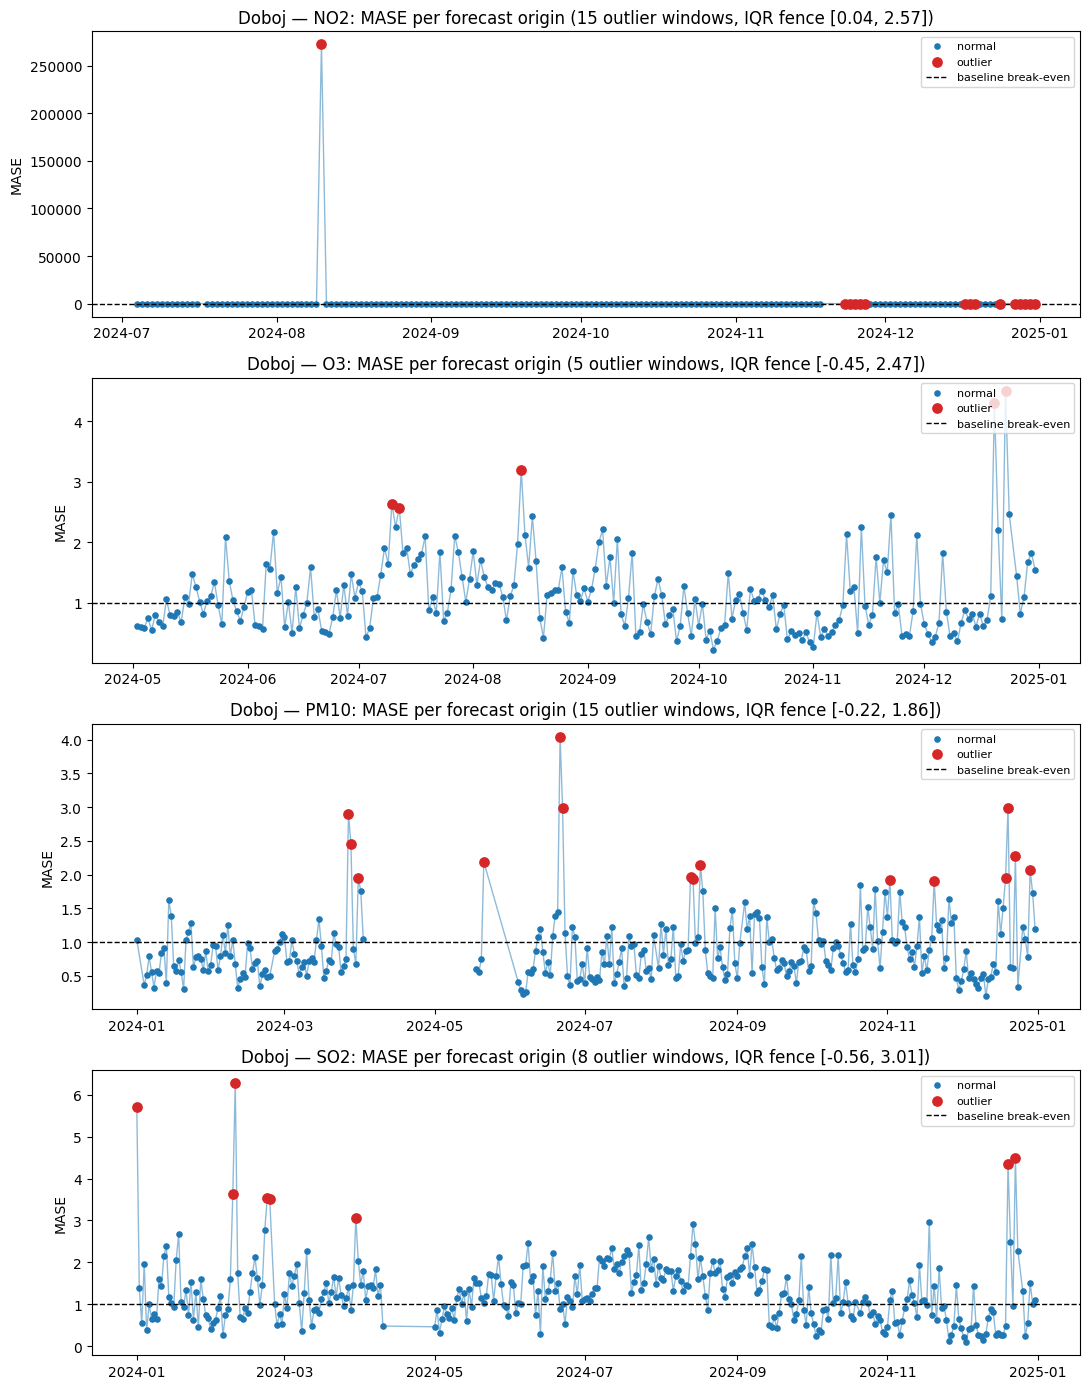


43 outlier windows across all Doboj pollutants:

pollutant     origin          mase           mae          rmse
      no2 2024-08-10 272561.285189 642246.544896 776426.264655
      so2 2024-02-10      6.278825      5.747994      6.363943
      so2 2024-01-01      5.715657      2.344805      2.861879
      no2 2024-12-30      5.205848     18.599713     20.280992
       o3 2024-12-23      4.510761      8.796133     10.703753
      so2 2024-12-23      4.479640      3.437426      3.999613
      so2 2024-12-20      4.348080      2.634856      3.088699
       o3 2024-12-20      4.299791      6.632419      7.616567
      no2 2024-11-26      4.182272      9.110369     10.298721
     pm10 2024-06-21      4.040506     36.228269     51.673522
      no2 2024-12-19      3.890263      8.610293     12.230635
      no2 2024-11-27      3.682394      8.375845      8.881905
      no2 2024-12-29      3.653503     12.779133     13.423186
      no2 2024-11-23      3.644801      7.573973      8.706703
     

In [3]:
"""
Doboj-only run + outlier inspection, layered on top of the existing xLSTM
script (xlstm_bih.py). Paste this after that script (or import from it) so
bs, SHARED_DIR, CLEAN_CSV, train_one_station, and evaluate are already
defined.

    from xlstm_bih import *   # or just paste this cell right after it
    full, per_pol = run_doboj()
    outliers = plot_doboj_outliers()
"""

import os
import pandas as pd


def run_doboj(lookback=168, horizon=24, epochs=20, device="cpu",
              out_csv="xlstm_doboj_results.csv"):
    """Same loop as run_all, but restricted to station == 'Doboj', across
    every pollutant Doboj is 'ok' for in groups.json. Appends incrementally
    and skips pairs already in out_csv, same resume behavior as run_all."""
    groups = bs.load_groups(SHARED_DIR)
    panel = bs.load_panel(CLEAN_CSV, SHARED_DIR)

    pairs = [(st, p) for p in bs.POLLUTANTS
             for st in groups["by_pollutant"][p]["ok"] if st == "Doboj"]

    if not pairs:
        status_by_pol = groups["by_station"].get("Doboj", {})
        raise ValueError(
            f"Doboj isn't 'ok' for any pollutant. Its statuses are: {status_by_pol}"
        )

    done = set()
    if os.path.exists(out_csv):
        prev = pd.read_csv(out_csv)
        done = set(zip(prev.station, prev.pollutant))
        print(f"{len(done)} Doboj pairs already in {out_csv}, skipping those")

    remaining = [pair for pair in pairs if pair not in done]
    print(f"Doboj: {len(pairs)} eligible pollutants total, {len(remaining)} left to train: {remaining}")

    for station, pollutant in remaining:
        try:
            model, val_ds, _, mu, sigma = train_one_station(
                station, pollutant, lookback=lookback, horizon=horizon,
                epochs=epochs, device=device)
            result, _ = evaluate(model, val_ds, panel, station, pollutant, mu, sigma, device=device)
            if len(result) == 0:
                continue
            header = not os.path.exists(out_csv)
            result.to_csv(out_csv, mode="a", header=header, index=False)
        except Exception as e:
            print(f"SKIPPED {station}-{pollutant}: {e}")

    full = pd.read_csv(out_csv)
    per_pol = bs.aggregate(full.to_dict("records"))
    print("\nDoboj summary, per pollutant, native units:\n")
    print(per_pol)
    return full, per_pol


def plot_doboj_outliers(out_csv="xlstm_doboj_results.csv", iqr_k=1.5):
    """Per-window MASE over time, one panel per pollutant Doboj has results
    for. Outlier windows are flagged with a Tukey IQR fence (q1-1.5*iqr,
    q3+1.5*iqr) computed per pollutant, since MASE scale differs across
    pollutants. Flags both directions — a window with implausibly low MASE
    is usually a scale/data artifact (e.g. a near-constant target hour),
    not the model suddenly getting much better, so it's worth checking too.
    """
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv, parse_dates=["origin"])
    full = full[full.station == "Doboj"]
    if len(full) == 0:
        print(f"no Doboj rows in {out_csv} yet — run run_doboj() first")
        return pd.DataFrame()

    pollutants = sorted(full.pollutant.unique())
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    outlier_rows = []
    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].sort_values("origin")
        q1, q3 = sub.mase.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - iqr_k * iqr, q3 + iqr_k * iqr
        is_out = (sub.mase < lo) | (sub.mase > hi)

        ax.plot(sub.origin, sub.mase, color="tab:blue", linewidth=1, alpha=0.5)
        ax.scatter(sub.origin[~is_out], sub.mase[~is_out], color="tab:blue", s=14, label="normal")
        ax.scatter(sub.origin[is_out], sub.mase[is_out], color="tab:red", s=45, zorder=5, label="outlier")
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="baseline break-even")
        ax.set_title(f"Doboj — {pollutant.upper()}: MASE per forecast origin "
                     f"({int(is_out.sum())} outlier windows, IQR fence [{lo:.2f}, {hi:.2f}])")
        ax.set_ylabel("MASE")
        ax.legend(loc="upper right", fontsize=8)

        outlier_rows.append(sub[is_out].assign(pollutant=pollutant))

    plt.tight_layout()
    plt.savefig("doboj_mase_outliers.png", dpi=150)
    plt.show()

    outliers = pd.concat(outlier_rows) if outlier_rows else pd.DataFrame()
    if len(outliers):
        cols = [c for c in ["pollutant", "origin", "mase", "mae", "rmse"] if c in outliers.columns]
        print(f"\n{len(outliers)} outlier windows across all Doboj pollutants:\n")
        print(outliers[cols].sort_values("mase", ascending=False).to_string(index=False))
    else:
        print("no outlier windows past the IQR fence")

    print("saved doboj_mase_outliers.png")
    return outliers


if __name__ == "__main__":
    full, per_pol = run_doboj()
    outliers = plot_doboj_outliers()

/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

4 Doboj pairs already in xlstm_doboj_results.csv, skipping those
Doboj: 4 eligible pollutants total, 0 left to train: []

Doboj summary, per pollutant, native units:

                         mae         rmse         mase
model pollutant                                       
xlstm no2        3673.546963  4441.136478  1567.867470
      o3            8.891166    11.341239     1.103548
      pm10         21.618642    27.192067     0.899326
      so2           3.829242     4.987586     1.301082


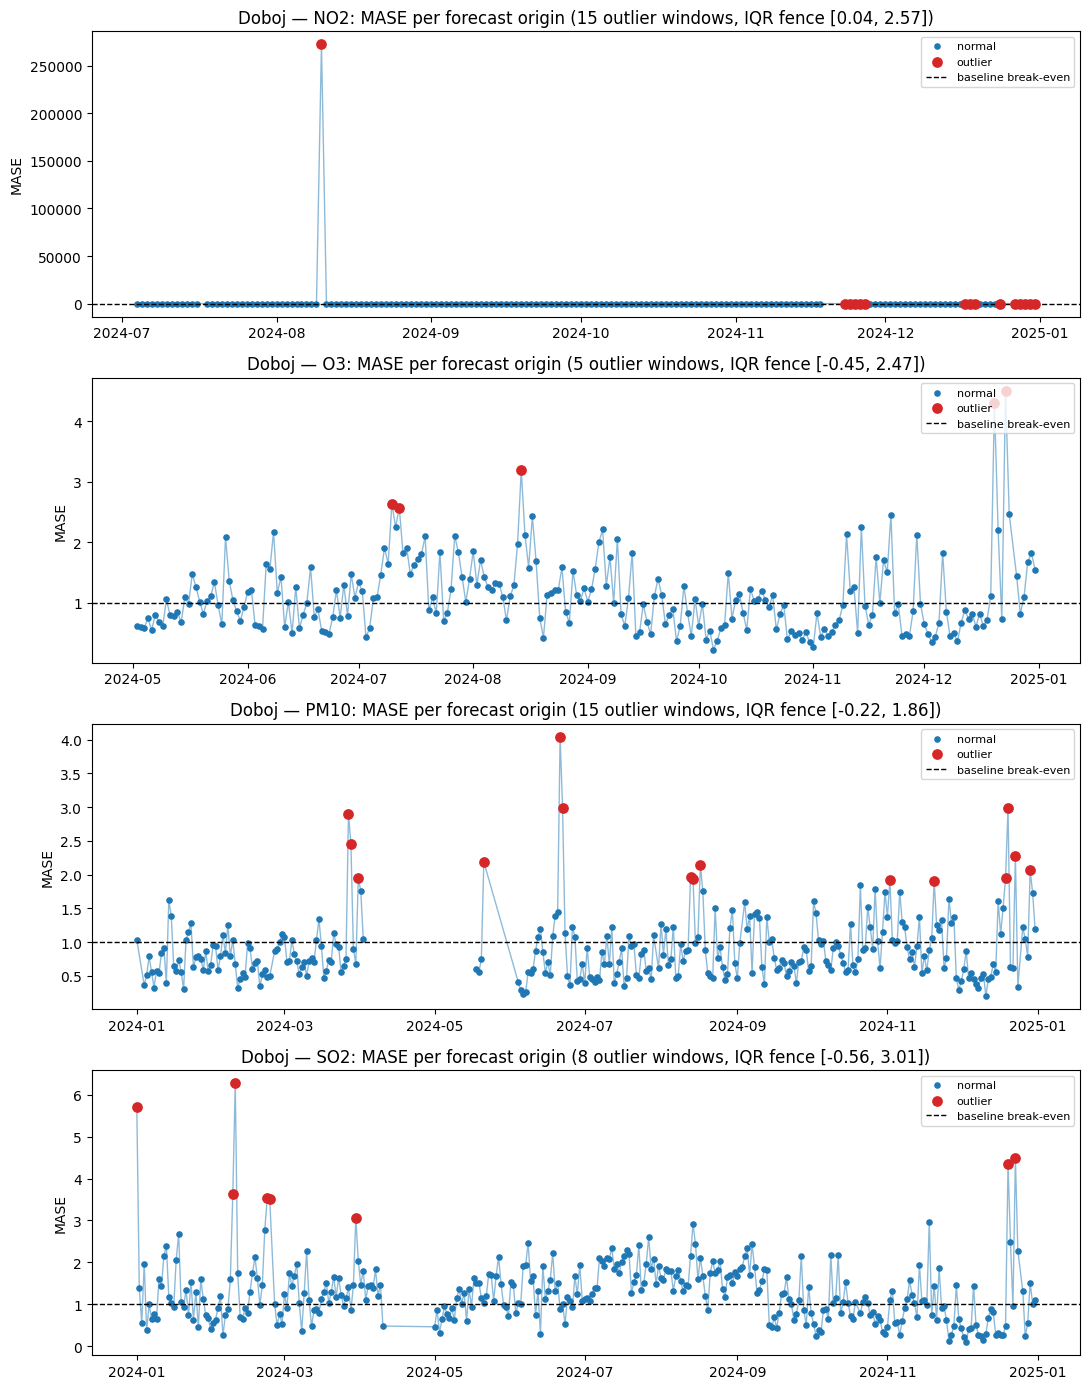


43 outlier windows across all Doboj pollutants:

pollutant     origin          mase           mae          rmse
      no2 2024-08-10 272561.285189 642246.544896 776426.264655
      so2 2024-02-10      6.278825      5.747994      6.363943
      so2 2024-01-01      5.715657      2.344805      2.861879
      no2 2024-12-30      5.205848     18.599713     20.280992
       o3 2024-12-23      4.510761      8.796133     10.703753
      so2 2024-12-23      4.479640      3.437426      3.999613
      so2 2024-12-20      4.348080      2.634856      3.088699
       o3 2024-12-20      4.299791      6.632419      7.616567
      no2 2024-11-26      4.182272      9.110369     10.298721
     pm10 2024-06-21      4.040506     36.228269     51.673522
      no2 2024-12-19      3.890263      8.610293     12.230635
      no2 2024-11-27      3.682394      8.375845      8.881905
      no2 2024-12-29      3.653503     12.779133     13.423186
      no2 2024-11-23      3.644801      7.573973      8.706703
     

In [4]:
full, per_pol = run_doboj()
outliers = plot_doboj_outliers()

worst window on record: origin=2024-08-10 00:00:00, mase=272561.28518862615

retraining this single pair to get a live model for inspection...


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-no2] epoch 1: train MAE (normalized)=50207.4198
[Doboj-no2] epoch 2: train MAE (normalized)=834.2710
[Doboj-no2] epoch 3: train MAE (normalized)=0.7913
[Doboj-no2] epoch 4: train MAE (normalized)=0.7781
[Doboj-no2] epoch 5: train MAE (normalized)=17.2777
[Doboj-no2] epoch 6: train MAE (normalized)=0.7616
[Doboj-no2] epoch 7: train MAE (normalized)=0.7551
[Doboj-no2] epoch 8: train MAE (normalized)=0.7495
[Doboj-no2] epoch 9: train MAE (normalized)=0.7443
[Doboj-no2] epoch 10: train MAE (normalized)=0.7389
[Doboj-no2] epoch 11: train MAE (normalized)=0.7362
[Doboj-no2] epoch 12: train MAE (normalized)=0.7317
[Doboj-no2] epoch 13: train MAE (normalized)=0.7281
[Doboj-no2] epoch 14: train MAE (normalized)=0.7255
[Doboj-no2] epoch 15: train MAE (normalized)=0.7232
[Doboj-no2] epoch 16: train MAE (normalized)=0.7207
[Doboj-no2] epoch 17: train MAE (normalized)=0.7191
[Doboj-no2] epoch 18: train MAE (normalized)=0.7177
[Doboj-no2] epoch 19: train MAE (normalized)=0.7171
[Doboj-no2] ep

ValueError: Axis limits cannot be NaN or Inf

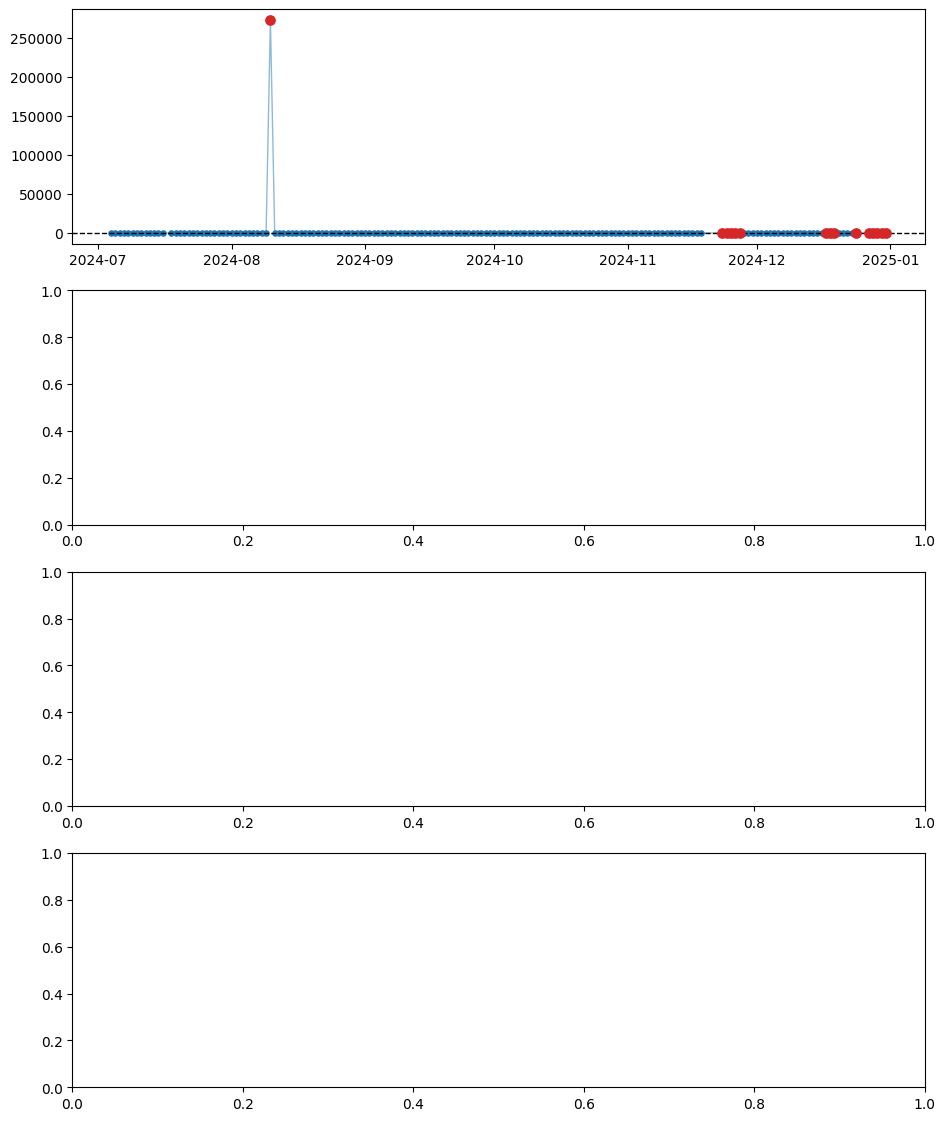

In [5]:
"""
Diagnostics for Doboj results — pinpoint why a single window's MASE
exploded, and a version of the outlier plot that doesn't let one degenerate
point flatten the y-axis for everything else.

Paste after the original xLSTM script AND doboj_analysis.py in the same
notebook session (needs bs, train_one_station, evaluate all already
defined).
"""

import numpy as np
import pandas as pd
import torch


def inspect_worst_window(station, pollutant, out_csv="xlstm_doboj_results.csv",
                          lookback=168, horizon=24, epochs=20, device="cpu"):
    """Finds the worst-MASE row for this station/pollutant in out_csv, then
    retrains that single pair (fast — it's one station-pollutant) to get a
    live model + panel, and prints the raw context/target/prediction/scale
    for that exact origin. This is what actually tells you whether a huge
    MASE is a real forecasting failure or a mase_scale ~ 0 artifact from a
    near-constant preceding week."""
    full = pd.read_csv(out_csv, parse_dates=["origin"])
    sub = full[(full.station == station) & (full.pollutant == pollutant)]
    if len(sub) == 0:
        raise ValueError(f"no rows for {station}-{pollutant} in {out_csv}")

    worst = sub.loc[sub.mase.idxmax()]
    origin = pd.Timestamp(worst.origin)
    print(f"worst window on record: origin={origin}, mase={worst.mase}")

    print("\nretraining this single pair to get a live model for inspection...")
    model, val_ds, panel, mu, sigma = train_one_station(
        station, pollutant, lookback=lookback, horizon=horizon,
        epochs=epochs, device=device)

    ctx = bs.context(panel, station, pollutant, origin, lookback)
    y, mask = bs.target(panel, station, pollutant, origin, horizon)
    wide_ctx = bs.context(panel, station, pollutant, origin, 512)
    scale = bs.mase_scale(wide_ctx)

    print(f"\n--- origin: {origin} ---")
    print(f"lookback context — last 24h: {np.round(ctx[-24:], 3)}")
    print(f"lookback context stats: min={np.nanmin(ctx):.3f} max={np.nanmax(ctx):.3f} "
          f"mean={np.nanmean(ctx):.3f} finite_count={np.isfinite(ctx).sum()}/{len(ctx)}")
    print(f"target y: {np.round(y, 3)}")
    print(f"target mask (1=real+unfilled, scored): {mask.astype(int)}")
    print(f"mase_scale (denominator, from 512h context): {scale}")
    if scale is None or not np.isfinite(scale) or scale < 1e-3:
        print("  ^ this is the smoking gun — a near-zero or degenerate scale "
              "means ANY nonzero error gets divided by ~nothing")

    if origin in list(val_ds.origins):
        idx = list(val_ds.origins).index(origin)
        x, y_norm, mask_t = val_ds[idx]
        with torch.no_grad():
            pred_norm = model(x.unsqueeze(0)).numpy()[0]
        pred = pred_norm * sigma + mu
        err = np.abs(pred - y) * mask
        mae = err.sum() / max(mask.sum(), 1)
        print(f"\nprediction: {np.round(pred, 3)}")
        print(f"abs error on scored hours: {np.round(err, 3)}")
        print(f"recomputed MAE: {mae:.4f}, MAE/scale (MASE): "
              f"{mae/scale if scale and scale > 1e-6 else 'undefined (scale ~0)'}")
    else:
        print("\n(this origin wasn't in this fresh val_ds — window eligibility "
              "may differ slightly run to run; the ctx/target/scale numbers above "
              "still hold)")

    return worst, ctx, y, mask, scale


def plot_doboj_outliers_clipped(out_csv="xlstm_doboj_results.csv", iqr_k=1.5,
                                 clip_percentile=95):
    """Same outlier plot as before, but the y-axis is clipped per pollutant
    at clip_percentile so one degenerate point (e.g. a mase_scale ~ 0
    window) can't flatten the rest of the series to an unreadable line.
    Anything above the clip is drawn as a triangle marker pinned at the
    axis ceiling and labeled with its real value, so you don't lose track
    of it — it's redrawn, not dropped."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv, parse_dates=["origin"])
    full = full[full.station == "Doboj"]
    if len(full) == 0:
        print(f"no Doboj rows in {out_csv} yet")
        return pd.DataFrame()

    pollutants = sorted(full.pollutant.unique())
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    outlier_rows = []
    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].sort_values("origin").reset_index(drop=True)
        q1, q3 = sub.mase.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - iqr_k * iqr, q3 + iqr_k * iqr
        is_out = (sub.mase < lo) | (sub.mase > hi)

        ceiling = max(np.percentile(sub.mase, clip_percentile) * 1.15, 1.5)
        off_chart = sub.mase > ceiling
        plotted_mase = sub.mase.clip(upper=ceiling)

        ax.plot(sub.origin, plotted_mase, color="tab:blue", linewidth=1, alpha=0.5)
        ax.scatter(sub.origin[~is_out & ~off_chart], plotted_mase[~is_out & ~off_chart],
                   color="tab:blue", s=14, label="normal")
        ax.scatter(sub.origin[is_out & ~off_chart], plotted_mase[is_out & ~off_chart],
                   color="tab:red", s=45, zorder=5, label="outlier")
        if off_chart.any():
            ax.scatter(sub.origin[off_chart], [ceiling] * off_chart.sum(),
                       color="darkred", marker="^", s=90, zorder=6, label="off-chart (see value)")
            for _, row in sub[off_chart].iterrows():
                ax.annotate(f"{row.mase:.0f}", (row.origin, ceiling),
                           textcoords="offset points", xytext=(0, 6),
                           ha="center", fontsize=8, color="darkred")
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="baseline break-even")
        ax.set_ylim(0, ceiling * 1.1)
        ax.set_title(f"Doboj — {pollutant.upper()}: MASE per forecast origin "
                     f"({int(is_out.sum())} outliers, IQR fence [{lo:.2f}, {hi:.2f}]"
                     f"{f', {off_chart.sum()} clipped off-chart' if off_chart.any() else ''})")
        ax.set_ylabel("MASE")
        ax.legend(loc="upper right", fontsize=8)

        outlier_rows.append(sub[is_out].assign(pollutant=pollutant))

    plt.tight_layout()
    plt.savefig("doboj_mase_outliers_clipped.png", dpi=150)
    plt.show()

    outliers = pd.concat(outlier_rows) if outlier_rows else pd.DataFrame()
    print("saved doboj_mase_outliers_clipped.png")
    return outliers


if __name__ == "__main__":
    inspect_worst_window("Doboj", "no2")
    plot_doboj_outliers_clipped()

worst window on record: origin=2024-08-10 00:00:00, mase=272561.28518862615

retraining this single pair to get a live model for inspection...


/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  "filled": g[f"{p}_filled"].fillna(False).to_numpy(bool)},
/content/shared/bih_shared.py:62: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcas

[Doboj-no2] epoch 1: train MAE (normalized)=60352.2808
[Doboj-no2] epoch 2: train MAE (normalized)=0.7998
[Doboj-no2] epoch 3: train MAE (normalized)=0.7823
[Doboj-no2] epoch 4: train MAE (normalized)=0.7689
[Doboj-no2] epoch 5: train MAE (normalized)=0.7619
[Doboj-no2] epoch 6: train MAE (normalized)=0.7572
[Doboj-no2] epoch 7: train MAE (normalized)=0.7521
[Doboj-no2] epoch 8: train MAE (normalized)=0.7471
[Doboj-no2] epoch 9: train MAE (normalized)=0.7431
[Doboj-no2] epoch 10: train MAE (normalized)=0.7400
[Doboj-no2] epoch 11: train MAE (normalized)=0.7374
[Doboj-no2] epoch 12: train MAE (normalized)=0.7383
[Doboj-no2] epoch 13: train MAE (normalized)=0.7339
[Doboj-no2] epoch 14: train MAE (normalized)=0.7308
[Doboj-no2] epoch 15: train MAE (normalized)=0.7292
[Doboj-no2] epoch 16: train MAE (normalized)=0.7294
[Doboj-no2] epoch 17: train MAE (normalized)=0.7256
[Doboj-no2] epoch 18: train MAE (normalized)=0.7238
[Doboj-no2] epoch 19: train MAE (normalized)=0.7213
[Doboj-no2] epoch

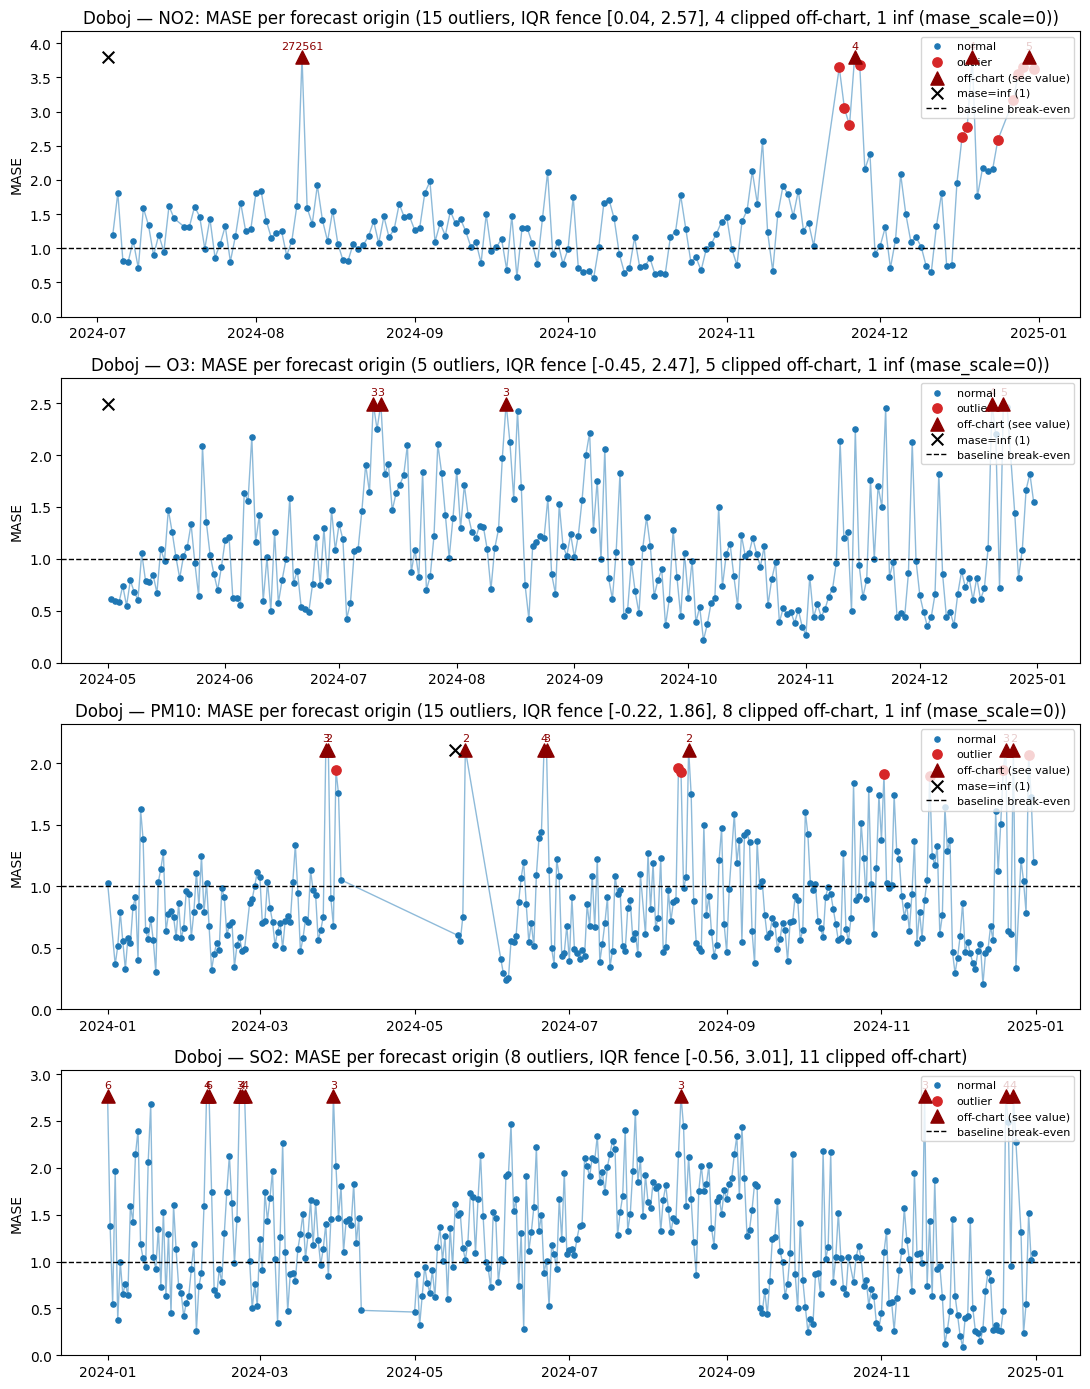

saved doboj_mase_outliers_clipped.png


FileNotFoundError: [Errno 2] No such file or directory: 'xlstm_results.csv'

In [6]:
"""
Diagnostics for Doboj results — pinpoint why a single window's MASE
exploded, and a version of the outlier plot that doesn't let one degenerate
point flatten the y-axis for everything else.

Paste after the original xLSTM script AND doboj_analysis.py in the same
notebook session (needs bs, train_one_station, evaluate all already
defined).
"""

import numpy as np
import pandas as pd
import torch


def inspect_worst_window(station, pollutant, out_csv="xlstm_doboj_results.csv",
                          lookback=168, horizon=24, epochs=20, device="cpu"):
    """Finds the worst-MASE row for this station/pollutant in out_csv, then
    retrains that single pair (fast — it's one station-pollutant) to get a
    live model + panel, and prints the raw context/target/prediction/scale
    for that exact origin. This is what actually tells you whether a huge
    MASE is a real forecasting failure or a mase_scale ~ 0 artifact from a
    near-constant preceding week."""
    full = pd.read_csv(out_csv, parse_dates=["origin"])
    sub = full[(full.station == station) & (full.pollutant == pollutant)]
    if len(sub) == 0:
        raise ValueError(f"no rows for {station}-{pollutant} in {out_csv}")

    worst = sub.loc[sub.mase.idxmax()]
    origin = pd.Timestamp(worst.origin)
    print(f"worst window on record: origin={origin}, mase={worst.mase}")

    print("\nretraining this single pair to get a live model for inspection...")
    model, val_ds, panel, mu, sigma = train_one_station(
        station, pollutant, lookback=lookback, horizon=horizon,
        epochs=epochs, device=device)

    ctx = bs.context(panel, station, pollutant, origin, lookback)
    y, mask = bs.target(panel, station, pollutant, origin, horizon)
    wide_ctx = bs.context(panel, station, pollutant, origin, 512)
    scale = bs.mase_scale(wide_ctx)

    print(f"\n--- origin: {origin} ---")
    print(f"lookback context — last 24h: {np.round(ctx[-24:], 3)}")
    print(f"lookback context stats: min={np.nanmin(ctx):.3f} max={np.nanmax(ctx):.3f} "
          f"mean={np.nanmean(ctx):.3f} finite_count={np.isfinite(ctx).sum()}/{len(ctx)}")
    print(f"target y: {np.round(y, 3)}")
    print(f"target mask (1=real+unfilled, scored): {mask.astype(int)}")
    print(f"mase_scale (denominator, from 512h context): {scale}")
    if scale is None or not np.isfinite(scale) or scale < 1e-3:
        print("  ^ this is the smoking gun — a near-zero or degenerate scale "
              "means ANY nonzero error gets divided by ~nothing")

    if origin in list(val_ds.origins):
        idx = list(val_ds.origins).index(origin)
        x, y_norm, mask_t = val_ds[idx]
        with torch.no_grad():
            pred_norm = model(x.unsqueeze(0)).numpy()[0]
        pred = pred_norm * sigma + mu
        err = np.abs(pred - y) * mask
        mae = err.sum() / max(mask.sum(), 1)
        print(f"\nprediction: {np.round(pred, 3)}")
        print(f"abs error on scored hours: {np.round(err, 3)}")
        print(f"recomputed MAE: {mae:.4f}, MAE/scale (MASE): "
              f"{mae/scale if scale and scale > 1e-6 else 'undefined (scale ~0)'}")
    else:
        print("\n(this origin wasn't in this fresh val_ds — window eligibility "
              "may differ slightly run to run; the ctx/target/scale numbers above "
              "still hold)")

    return worst, ctx, y, mask, scale


def plot_doboj_outliers_clipped(out_csv="xlstm_doboj_results.csv", iqr_k=1.5,
                                 clip_percentile=95):
    """Same outlier plot as before, but the y-axis is clipped per pollutant
    at clip_percentile so one degenerate point (e.g. a mase_scale ~ 0
    window) can't flatten the rest of the series to an unreadable line.
    Anything above the clip is drawn as a triangle marker pinned at the
    axis ceiling and labeled with its real value, so you don't lose track
    of it — it's redrawn, not dropped."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv, parse_dates=["origin"])
    full = full[full.station == "Doboj"]
    if len(full) == 0:
        print(f"no Doboj rows in {out_csv} yet")
        return pd.DataFrame()

    pollutants = sorted(full.pollutant.unique())
    fig, axes = plt.subplots(len(pollutants), 1, figsize=(11, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    outlier_rows = []
    invalid_rows = []
    for ax, pollutant in zip(axes, pollutants):
        sub = full[full.pollutant == pollutant].sort_values("origin").reset_index(drop=True)

        # mase_scale == 0 for some window makes mase == inf, not just "big" —
        # inf/NaN poison quantile/percentile/set_ylim, so pull them out first
        # and treat them as their own category rather than plotting them.
        is_bad = ~np.isfinite(sub.mase)
        finite = sub[~is_bad]
        if is_bad.any():
            invalid_rows.append(sub[is_bad].assign(pollutant=pollutant))
        if len(finite) == 0:
            print(f"{pollutant}: every window has non-finite MASE (mase_scale==0 everywhere?) — skipping plot")
            continue

        q1, q3 = finite.mase.quantile([0.25, 0.75])
        iqr = q3 - q1
        lo, hi = q1 - iqr_k * iqr, q3 + iqr_k * iqr
        is_out = (finite.mase < lo) | (finite.mase > hi)

        ceiling = max(np.percentile(finite.mase, clip_percentile) * 1.15, 1.5)
        off_chart = finite.mase > ceiling
        plotted_mase = finite.mase.clip(upper=ceiling)

        ax.plot(finite.origin, plotted_mase, color="tab:blue", linewidth=1, alpha=0.5)
        ax.scatter(finite.origin[~is_out & ~off_chart], plotted_mase[~is_out & ~off_chart],
                   color="tab:blue", s=14, label="normal")
        ax.scatter(finite.origin[is_out & ~off_chart], plotted_mase[is_out & ~off_chart],
                   color="tab:red", s=45, zorder=5, label="outlier")
        if off_chart.any():
            ax.scatter(finite.origin[off_chart], [ceiling] * off_chart.sum(),
                       color="darkred", marker="^", s=90, zorder=6, label="off-chart (see value)")
            for _, row in finite[off_chart].iterrows():
                ax.annotate(f"{row.mase:.0f}", (row.origin, ceiling),
                           textcoords="offset points", xytext=(0, 6),
                           ha="center", fontsize=8, color="darkred")
        if is_bad.any():
            # plot inf/NaN windows as a distinct marker pinned at the ceiling
            bad_x = sub.origin[is_bad]
            ax.scatter(bad_x, [ceiling] * len(bad_x), color="black", marker="x", s=70,
                       zorder=7, label=f"mase=inf ({is_bad.sum()})")
        ax.axhline(1.0, color="black", linestyle="--", linewidth=1, label="baseline break-even")
        ax.set_ylim(0, ceiling * 1.1)
        n_off = int(off_chart.sum())
        ax.set_title(f"Doboj — {pollutant.upper()}: MASE per forecast origin "
                     f"({int(is_out.sum())} outliers, IQR fence [{lo:.2f}, {hi:.2f}]"
                     f"{f', {n_off} clipped off-chart' if n_off else ''}"
                     f"{f', {int(is_bad.sum())} inf (mase_scale=0)' if is_bad.any() else ''})")
        ax.set_ylabel("MASE")
        ax.legend(loc="upper right", fontsize=8)

        outlier_rows.append(finite[is_out].assign(pollutant=pollutant))

    if invalid_rows:
        bad_all = pd.concat(invalid_rows)
        print(f"\n{len(bad_all)} windows had non-finite MASE (mase_scale==0) — "
              "these are excluded from the outlier stats above, not silently averaged in:")
        print(bad_all[["pollutant", "origin"]].to_string(index=False))

    plt.tight_layout()
    plt.savefig("doboj_mase_outliers_clipped.png", dpi=150)
    plt.show()

    outliers = pd.concat(outlier_rows) if outlier_rows else pd.DataFrame()
    print("saved doboj_mase_outliers_clipped.png")
    return outliers


def plot_station_summary_robust(out_csv="xlstm_results.csv"):
    """Fixed version of plot_results: uses the MEDIAN mase per station
    instead of the mean. A mean is dragged arbitrarily far by a single
    degenerate window (mase_scale ~ 0); the median isn't, so this actually
    shows whether a station's typical window beats the baseline, rather
    than being hijacked by one outlier. Also prints, per station/pollutant,
    how many windows exceed mase=50 as a red flag for scale-artifact
    contamination worth cleaning up before trusting the mean at all."""
    import matplotlib.pyplot as plt

    full = pd.read_csv(out_csv)
    pollutants = sorted(full.pollutant.unique())

    n_inf = (~np.isfinite(full.mase)).sum()
    if n_inf:
        print(f"{n_inf} windows have non-finite MASE (mase_scale==0) — excluded from every stat below")
    finite_full = full[np.isfinite(full.mase)]

    print("\nwindows with mase > 50 (near-certain mase_scale artifacts), per station/pollutant:")
    blowups = finite_full[finite_full.mase > 50].groupby(["station", "pollutant"]).size()
    print(blowups.to_string() if len(blowups) else "  none")

    fig, axes = plt.subplots(len(pollutants), 1, figsize=(10, 3.5 * len(pollutants)), squeeze=False)
    axes = axes.ravel()

    for ax, pollutant in zip(axes, pollutants):
        sub = finite_full[finite_full.pollutant == pollutant].groupby("station").mase.median().sort_values()
        if len(sub) == 0 or not np.isfinite(sub.values).all():
            ax.set_title(f"{pollutant.upper()} — no finite data to plot")
            continue
        colors = ["tab:green" if v < 1.0 else "tab:red" for v in sub.values]
        ax.barh(sub.index, sub.values, color=colors)
        ax.axvline(1.0, color="black", linestyle="--", linewidth=1)
        ax.set_title(f"{pollutant.upper()} — MEDIAN MASE by station (below 1.0 beats the baseline)")
        ax.set_xlabel("MASE")

    plt.tight_layout()
    plt.savefig("xlstm_mase_by_station_median.png", dpi=150)
    plt.show()
    print("saved xlstm_mase_by_station_median.png")


if __name__ == "__main__":
    inspect_worst_window("Doboj", "no2")
    plot_doboj_outliers_clipped()
    plot_station_summary_robust()